<a href="https://colab.research.google.com/github/Jerefilms/DEEP-LEARNING/blob/main/trabajo1-deeplearning-davidcelis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


/
---
DEEP LEARNING /
SAMUEL DAVID CELIS JEREMICHE/
POSGRADO INTELIGENCIA ARTIFICIAL/


/

Primero vamos a importar librerias

In [1]:
import numpy as np
import matplotlib.pyplot as plt

PERCEPTRON BASICO FUNCIONAL


Época 1: 2 errores
Época 2: 2 errores
Época 3: 1 errores
Época 4: 0 errores
Época 5: 0 errores
Época 6: 0 errores


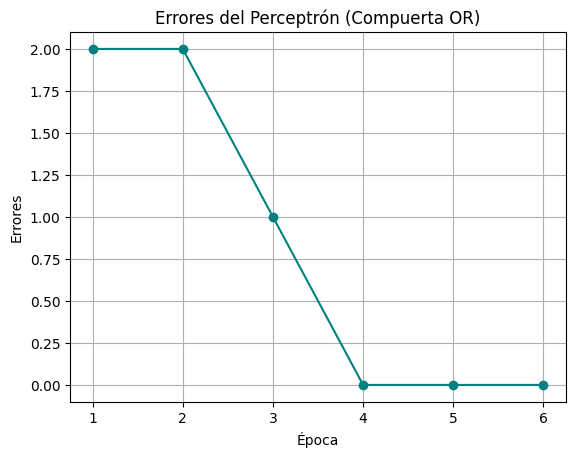

In [4]:
# Aca vamos a definir las Entradas ES DECIR las posibles conbionaciones,
#Antes de poner a entrenar al perceptrón, hay que darle sus valores de salida,
#Los pesos marcan qué tanto le importa cada dato de entrada y van a empezar en cero porque la neurona básicamente no sabe nada todavía
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Relizamos la tabla de la verdad entre 0 y 1
y_or = np.array([0, 1, 1, 1])

class Perceptron:
    def __init__(self, n_entradas=2, lr=0.1):
        self.pesos = np.zeros(n_entradas)
        self.sesgo = 0.0
        self.lr = lr  # Tasa de aprendizaje

    def activar(self, z):
        # esto devuelve si es 1
        return 1 if z >= 0 else 0

    def predecir(self, x):
        z = np.dot(x, self.pesos) + self.sesgo
        return self.activar(z)

    def entrenar(self, X, y, epocas=10):
        historial_errores = []

        for epoca in range(epocas):
            errores = 0
            for i in range(len(X)):
                prediccion = self.predecir(X[i])
                error = y[i] - prediccion

                # Si falla entonces se corrige el peso y el sesgo
                if error != 0:
                    self.pesos += self.lr * error * X[i]
                    self.sesgo += self.lr * error
                    errores += 1

            historial_errores.append(errores)
            print(f"Época {epoca + 1}: {errores} errores")

        return historial_errores

# y con esta linea de codigo comenzamos a entrenar la neuroa
modelo_p = Perceptron(lr=0.1)
errores = modelo_p.entrenar(X, y_or, epocas=6)

# y graficamos el resultado
plt.plot(range(1, len(errores) + 1), errores, marker='o', color='teal')
plt.title('Errores del Perceptrón (Compuerta OR)')
plt.xlabel('Época')
plt.ylabel('Errores')
plt.grid(True)
plt.show()

Red Neuronal de Una Capa
Ahora dejamos la función escaloon y usamos la cigmoide, que nos da una probabilidad suave entre 0 y 1 . Como la cigmoide es derivable, podemos usar el descenso de gradiente para ir corrigiendo los errores de forma continua.

In [6]:
# colocamos los datos para la compuerta and
y_and = np.array([[0], [0], [0], [1]])

def sigmoide(z):
    return 1 / (1 + np.exp(-z))

def derivada_sigmoide(a):
    return a * (1 - a)

# inicializamos pesos al azar y sesgo en 0
np.random.seed(1)
w = np.random.randn(2, 1) * 0.1
b = 0.0
lr = 0.5

historial_loss = []

for epoca in range(1000):
    # Forward: calculamos la prediccion
    z = np.dot(X, w) + b
    prediccion = sigmoide(z)

    # Error y posible perdoda
    error = prediccion - y_and
    loss = np.mean(error ** 2)
    historial_loss.append(loss)

    # aca calculamos la escala de gradientes
    d_z = error * derivada_sigmoide(prediccion)
    d_w = np.dot(X.T, d_z) / len(X)
    d_b = np.sum(d_z) / len(X)

    # Dentro de esta linea de codigo actualizamos los parametros
    w -= lr * d_w
    b -= lr * d_b

print("Resultados Red 1 Capa (AND):")
for i in range(len(X)):
    pred = sigmoide(np.dot(X[i], w) + b)[0]
    print(f"Entrada: {X[i]} -> Predicción: {pred:.3f} (Redondeado: {round(pred)})")

Resultados Red 1 Capa (AND):
Entrada: [0 0] -> Predicción: 0.011 (Redondeado: 0)
Entrada: [0 1] -> Predicción: 0.173 (Redondeado: 0)
Entrada: [1 0] -> Predicción: 0.173 (Redondeado: 0)
Entrada: [1 1] -> Predicción: 0.790 (Redondeado: 1)


Red Neuronal Multicapa  para resolver XOR
Las redes de 1 capa solo pueden dibujar una línea recta para dividir los datos.
La capa oculta transforma los datos para poder doblar ese espacio y separar los patrones correctamente.


Resultados Red Multicapa (XOR):
Entrada: [0 0] -> Predicción: 0.037 (Redondeado: 0) | Esperado: 0
Entrada: [0 1] -> Predicción: 0.949 (Redondeado: 1) | Esperado: 1
Entrada: [1 0] -> Predicción: 0.945 (Redondeado: 1) | Esperado: 1
Entrada: [1 1] -> Predicción: 0.064 (Redondeado: 0) | Esperado: 0


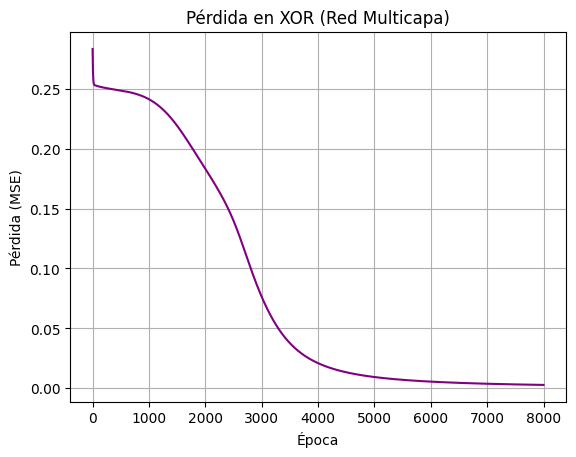

In [9]:
# Tabla de verdad de XOR con 0 y 1
y_xor = np.array([[0], [1], [1], [0]])


#tenemos que definir de nuevo sigmoide porque no es el mismo codigo de arriba
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

def derivada_sigmoide(a):
    return a * (1 - a)

# colocamos el tamaño de las capas corespodientes
n_in = 2      #2 entradas
n_hidden = 4  #4 neuronas ocultas
n_out = 1     # 1 salida

np.random.seed(42)
# aca colocamos los pesos inciales
W1 = np.random.randn(n_in, n_hidden)
b1 = np.zeros((1, n_hidden))
W2 = np.random.randn(n_hidden, n_out)
b2 = np.zeros((1, n_out))

lr = 0.5
errores_mlp = []

for epoca in range(8000):
    # paso hacia alf rente
    capa_oculta = sigmoide(np.dot(X, W1) + b1)
    salida = sigmoide(np.dot(capa_oculta, W2) + b2)

    # se calcula el error
    error_salida = salida - y_xor
    loss = np.mean(error_salida ** 2)
    errores_mlp.append(loss)

    # Paso hacia atras
    delta_salida = error_salida * derivada_sigmoide(salida)

    error_oculta = np.dot(delta_salida, W2.T)
    delta_oculta = error_oculta * derivada_sigmoide(capa_oculta)

    # aca se actualizan los pesos
    W2 -= lr * np.dot(capa_oculta.T, delta_salida) / len(X)
    b2 -= lr * np.sum(delta_salida, axis=0, keepdims=True) / len(X)
    W1 -= lr * np.dot(X.T, delta_oculta) / len(X)
    b1 -= lr * np.sum(delta_oculta, axis=0, keepdims=True) / len(X)

print("\nResultados Red Multicapa (XOR):")
for i in range(len(X)):
    h = sigmoide(np.dot(X[i], W1) + b1)
    out = sigmoide(np.dot(h, W2) + b2)[0][0]
    print(f"Entrada: {X[i]} -> Predicción: {out:.3f} (Redondeado: {round(out)}) | Esperado: {y_xor[i][0]}")

# generamos la grafica de error
plt.plot(errores_mlp, color='purple')
plt.title('Pérdida en XOR (Red Multicapa)')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.grid(True)
plt.show()